In [1]:
# Consolidated library (was: %run Packages.ipynb / Cycle_Mtx_functions / Graph_Generators /
# Metric_Repair_Algorithms -- those split files now live only in Archive/).
%run Packages_and_Functions.ipynb

2.989999999999995
4.7999999999999945
2.9099999999999957
2.989999999999995
4.719999999999996
2.889999999999996


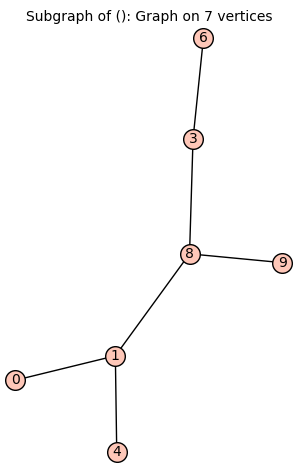

In [84]:
G = random_geometric_weighted_graph(10,.5)
def diameter(G,weighted=True):
    if weighted:
        apsp = G.distance_all_pairs(by_weight=True)
        diam = 0
        for v in G.vertices(sort=1):
            diam = max((diam,max(apsp[v].values())))
        return diam
    else:
        return G.diameter()

def giant_component(G):
    return G.subgraph(G.connected_components()[0])

In [104]:
### Time to run an experiment! the average diameter of a random geometric graph with p = lambda/n, lambda varying

N = 40 # length of partition
Lambda = np.linspace(1,10,N) 
n = 200 # number of vertices
T = 50 # over how many iterations to compute the average
res = np.zeros((2,N))
for i,lam in enumerate(Lambda):
    for t in range(T):
        G = random_geometric_weighted_graph(n,lam/n)
        H = giant_component(G)
        res[0,i] += diameter(H)/T
        res[1,i] += diameter(H,weighted=0)/T


    

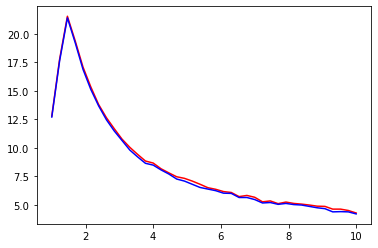

In [105]:
plt.plot(Lambda,res[0],color='r')
plt.plot(Lambda,res[1],color='b')
# plt.vlines(x=4.6,ymin=0,ymax=10)
plt.show()